# Результаты

Время вылета и прилета в датасетах судя по всему по местному времени. Проверить это можно поиском по depTime >= arrTime. Если мы вылетели позже чем прилетели значит мы либо летели в прошлое, либо летели в другой часовой пояс. Первое невозможно поэтому второе.

Для решения этой проблемы надо привести все вылеты в один часовой пояс а дату прибытия считать как время вылета + время полета. Для этого заимпортируем второй [датасет с часовыми поясами](https://www.kaggle.com/datasets/daviersnchez/us-airports-timezones).

Однако, в штатах все еще есть летнее время (ведь так удобно менять время 2 раза в год). Но я как нормальный человек буду считать США нормальными и что они живут по зимнему времени и не буду учитывать переходы на разное время.

Встречаются так же вылеты сегодня в 24:00 -> завтра в 00 (зачем так писать? как будто не для людей делают)

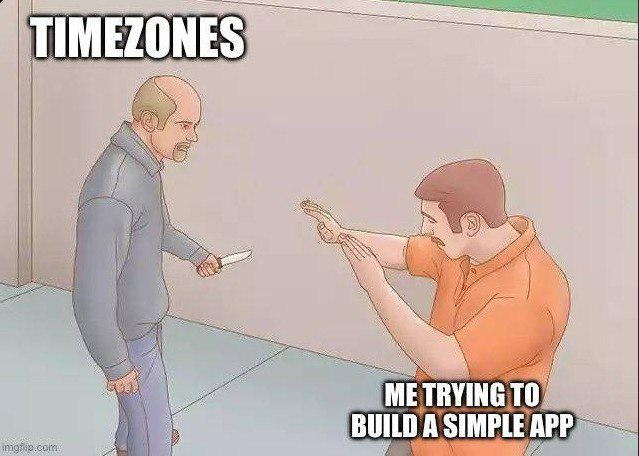

## Выводы

По scatterplot'ам особо не удается установить какую-либо зависимость. Так же как и при расчете корреляции Пирсона.

Однако при расчете корреляции Спирмана удалось найти некоторые корреляции:
- Медианное время заражения орбратно коррелирует с степенью. Что странно. Ведь чем больше связей, тем больше шанс заражения. Здесь скорее всего сказывается ненаправленность графа. Ведь из аэропорта с большим числом связей самолеты могли в основном вылетать, а прилетать из какого-то одного.
Например из аэропорта А вылетели самолеты в Б, В, Г, затем они полетели в Э, Ю, оттуда в Я и затем вернулись в Я из А.
- Остальные метрики (кроме медианы) имеют положительную корреляцию. Чем больше кластеризация, тем больше связей у узла и тем чаще узел встречается как посредник.

Я ожидал увидеть большую связь между метриками и заражением. Возможно просто мне не везет на заразность. Либо у аэропорта ABE не так много перелетов в крупные хабы, откуда зараза будет разлетаться хорошо

In [323]:
from datetime import datetime, timedelta, timezone
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns    
from tqdm import tqdm
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

In [2]:
tz_path = kagglehub.dataset_download("daviersnchez/us-airports-timezones")
tz = pd.read_csv(f"{tz_path}/airports_and_timezones.csv", index_col="iata")
# Добавление аэропортов, о которых нет информации
tz.loc["SLE"] = ["Salem-Willamette Valley Airport", "Salem", "Oregon", 44.909534, -123.002496, "Pacific Standard Time (PST)", -8]
tz.loc["YKM"] = ["Yakima Air Terminal", "Yakima", "Washington", 46.5682, -120.5440, "Pacific Standard Time (PST)", -8]
tz.loc["PMD"] = ["Palmdale Regional Airport", "Palmdale", "California", 34.6294, -118.0846, "Pacific Standard Time (PST)", -8]
tz.loc["HHH"] = ["Hilton Head Airport", "Hilton Head Island", "South Carolina", 32.2244, -80.6975, "Eastern Standard Time (EST)", -5]
tz.loc["OGD"] = ["Ogden-Hinckley Airport", "Ogden", "Utah", 41.1959, -112.0123, "Mountain Standard Time (MST)", -7]

path = kagglehub.dataset_download("vikalpdongre/us-flights-data-2008")

data = pd.read_csv(f"{path}/2008.csv")

origin_airports = set(data["Origin"].unique()) - set(tz.index)
if origin_airports:
    raise ValueError(f"Нехватает аэропортов вылета: {origin_airports}")

dest_airports = set(data["Dest"].unique()) - set(tz.index)
if dest_airports:
    raise ValueError(f"Нехватает аэропортов прибытия: {dest_airports}")

In [3]:
# нам неинтересны отмененные рейсы
# нам неинтересны возвращенные рейсы, у них не указана дата прилета и неизвестно куда именно они вернулись
# будем считать что они вернулись в город вылета -> нам неинтересно
data.drop(data[(data["Cancelled"] == 1) | (data["Diverted"] == 1)].index, inplace=True)

def cast_to_int(col):
    non_integer_count = (data[col] % 1 != 0).sum()
    print(f"Количество нецелых значений в '{col}': {non_integer_count}")
    if not non_integer_count:
        data[col] = data[col].astype(int)
        
cast_to_int("DepTime")
cast_to_int("ArrTime")
cast_to_int("ActualElapsedTime")

def create_timezone(hours_offset, minutes_offset=0):
    """Создает временную зону по смещению"""
    offset = timedelta(hours=int(hours_offset), minutes=minutes_offset)
    return timezone(offset)

def to_timezone(row):
    row_timezone = create_timezone(tz.loc[row["Origin"]]["gmt_offset"])
    hour = row["DepTime"] // 100
    add_days = timedelta(days=1)
    # если вылет сегодня в полночь, значит завтра в 00 
    if hour == 24:
        add_days = timedelta(days=1)
        hour = 0
    new_date = datetime(row["Year"], row["Month"], row["DayofMonth"], hour, row["DepTime"] % 100, tzinfo=row_timezone)
    return pd.Timestamp((new_date + add_days)).tz_convert('UTC')
    
data["DepTime_Tz"] = data.apply(to_timezone, axis=1)
data["ArrTime_Tz"] = data.apply(lambda row: row["DepTime_Tz"] + timedelta(minutes=row["ActualElapsedTime"]), axis=1)

cols_to_drop = [
    "CRSDepTime",
    "CRSArrTime",
    # "ActualElapsedTime", # т.к. мы будем считать время прилета, то нам нужно это время
    # "ArrTime", # а это не нужно т.к. его мы посчитаем сами
    "CRSElapsedTime",
    "AirTime",
    "ArrDelay",
    "DepDelay",
    "Distance",
    "TaxiIn",
    "TaxiOut",
    "Cancelled",
    "CancellationCode",
    "Diverted",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

data.drop(cols_to_drop, axis=1, inplace=True)

# Сортируем по времени прибытия
data.sort_values("DepTime_Tz", inplace=True)

data.info()

Количество нецелых значений в 'DepTime': 0
Количество нецелых значений в 'ArrTime': 0
Количество нецелых значений в 'ActualElapsedTime': 0
<class 'pandas.core.frame.DataFrame'>
Index: 6855029 entries, 354001 to 6663085
Data columns (total 14 columns):
 #   Column             Dtype              
---  ------             -----              
 0   Year               int64              
 1   Month              int64              
 2   DayofMonth         int64              
 3   DayOfWeek          int64              
 4   DepTime            int64              
 5   ArrTime            int64              
 6   UniqueCarrier      object             
 7   FlightNum          int64              
 8   TailNum            object             
 9   ActualElapsedTime  int64              
 10  Origin             object             
 11  Dest               object             
 12  DepTime_Tz         datetime64[ns, UTC]
 13  ArrTime_Tz         datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2), int64(8), ob

In [347]:
data.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,Origin,Dest,DepTime_Tz,ArrTime_Tz
354001,2008,1,1,2,2,57,FL,579,N937AT,55,ATL,CHS,2008-01-02 05:02:00+00:00,2008-01-02 05:57:00+00:00
115630,2008,1,1,2,3,230,XE,2895,N14158,207,CLE,SAT,2008-01-02 05:03:00+00:00,2008-01-02 08:30:00+00:00
129414,2008,1,1,2,5,132,YV,7185,N592ML,87,IAD,CLE,2008-01-02 05:05:00+00:00,2008-01-02 06:32:00+00:00
546586,2008,1,1,2,8,332,B6,859,N505JB,204,JFK,PBI,2008-01-02 05:08:00+00:00,2008-01-02 08:32:00+00:00
453677,2008,1,1,2,9,215,OH,5169,N669CA,126,CVG,MHT,2008-01-02 05:09:00+00:00,2008-01-02 07:15:00+00:00


In [346]:
data.describe()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,FlightNum,ActualElapsedTime
count,6855029.0,6.855029e+06,6.855029e+06,6.855029e+06,6.855029e+06,6.855029e+06,6.855029e+06,6.855029e+06
mean,2008.0,6.388525e+00,1.573826e+01,3.925802e+00,1.333775e+03,1.481266e+03,2.212507e+03,1.273224e+02
std,0.0,3.398833e+00,8.801086e+00,1.988459e+00,4.780574e+02,5.051322e+02,1.956437e+03,7.018731e+01
min,2008.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01
25%,2008.0,3.000000e+00,8.000000e+00,2.000000e+00,9.280000e+02,1.107000e+03,6.180000e+02,7.700000e+01
50%,2008.0,6.000000e+00,1.600000e+01,4.000000e+00,1.325000e+03,1.512000e+03,1.563000e+03,1.100000e+02
75%,2008.0,9.000000e+00,2.300000e+01,6.000000e+00,1.728000e+03,1.909000e+03,3.494000e+03,1.570000e+02
max,2008.0,1.200000e+01,3.100000e+01,7.000000e+00,2.400000e+03,2.400000e+03,9.741000e+03,1.379000e+03


In [357]:
print(f"Всего перелотов из ABE: {data[data['Origin'] == 'ABE']['Origin'].count()}")
for airport in data[data["Origin"] == "ABE"]["Dest"].unique():
    print(tz.loc[airport]["airport"])

Всего перелотов из ABE: 4642
Detroit Metropolitan-Wayne County
Chicago O'Hare International
Charlotte Douglas International
William B Hartsfield-Atlanta Intl
Cleveland-Hopkins Intl
Cincinnati Northern Kentucky Intl
John F Kennedy Intl
LaGuardia
Philadelphia Intl
Birmingham International


In [ ]:
def simulate_infection(data, p, start_from="ABE", random_state=42):
    if not start_from:
        start_from = data.sample(1, random_state=42).iloc[0]["Origin"]
    
    np.random.seed(random_state)
    
    # изначальный город откуда идет заражение. Он уже заражен поэтому считаем что он заразился в самом начале года
    infection_started = data.iloc[0]["DepTime_Tz"].replace(month=1, day=1, hour=0, minute=0, second=0, microsecond=0)
    infected = {start_from: infection_started}
    
    for row in data.itertuples():
        # Если город был заражен раньше чем отправляется текущий рейс 
        origin_city_infected = row.Origin in infected and infected[row.Origin] < row.DepTime_Tz
        # Если город отправления заражен и случилось заражение рейса
        destination_airport_infected = True if origin_city_infected and np.random.rand() < p else False
        # Если рейс заражен, то устанавливаем время заражения города назначения
        if destination_airport_infected:
            if row.Dest in infected:
                infected[row.Dest] = min(row.ArrTime_Tz, infected[row.Dest])
            else:
                infected[row.Dest] = row.ArrTime_Tz
    
    return infected

def run_simulations(data, p, n=10, random_state=42):
    results = []
    np.random.seed(random_state)
    for _ in tqdm(range(n), desc=f"Симуляция для p={p}"):
        results.append(simulate_infection(data, p, random_state=np.random.randint(random_state)))
    return results

In [7]:
simulations = {
    1: run_simulations(data, 0.01, random_state=42*1),
    5: run_simulations(data, 0.05, random_state=42*2),
    10: run_simulations(data, 0.1, random_state=42*3),
    50: run_simulations(data, 0.5, random_state=42*4),
    100: run_simulations(data, 1, random_state=42*5),
}

Симуляция для p=1: 100%|██████████| 10/10 [03:53<00:00, 23.34s/it]


In [ ]:
def count_infected_airports(infected, hours_window=12):
    dates = list(infected.values())
    dates.sort()
    
    first_date = dates[0]
    count = 1
    
    result = {1:count} # для 0 первых часов 1 город заражения, стартовый
    
    
    for i in range(1, len(dates)):
        date = dates[i]
        count += 1
        hours = int(((date - first_date).total_seconds() / 60 / 60) // hours_window) + 1
        result[hours * hours_window] = count
    
    return result

def mean_infected_airports(infected_counts):
    max_hour = max([max(infected_count.keys()) for infected_count in infected_counts])
    result = []
    
    last_existent_hour = [1 for _ in infected_counts]
    
    for hour in range(max_hour + 1):
        result_sum = 0
        for i in range(len(infected_counts)):
            if hour in infected_counts[i]:
                last_existent_hour[i] = hour
            result_sum += infected_counts[i][last_existent_hour[i]]
        result_sum /= len(infected_counts)
        if not result or result_sum != result[-1][1]:
            result.append((hour, result_sum))
        
    return result 
    

Text(0.5, 1.0, 'Среднее количество зараженных аэропортов (симуляций: 10)')

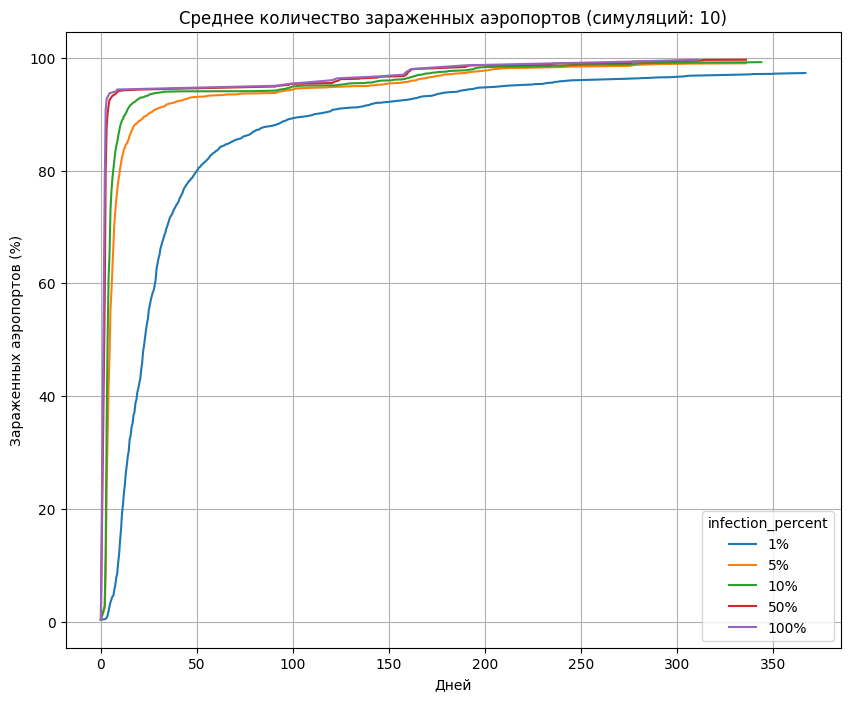

In [148]:
total_airports = len(set(data["Origin"].unique()).union(set(data["Dest"].unique())))

x_values_result = []
y_values_result = []
hue_values_result = []

for p, simulation in simulations.items():
    count = []
    for sim in simulation:
        count.append(count_infected_airports(sim))

    # Приведение к дням потому что считать визуализировать в часах не очень удобно.
    percent_vals = [(hour / 24, mean / total_airports * 100) for hour, mean in mean_infected_airports(count)]
    
    x_values_result.extend([point[0] for point in percent_vals])
    y_values_result.extend([point[1] for point in percent_vals])
    hue_values_result.extend([f"{p}%" for _ in percent_vals])
    
percent_df = pd.DataFrame({"x":x_values_result, "y":y_values_result, "infection_percent":hue_values_result})
plt.figure(figsize=(10,8))
sns.lineplot(percent_df, x="x", y="y", hue="infection_percent")
plt.grid()
plt.xlabel("Дней")
plt.ylabel("Зараженных аэропортов (%)")
plt.title(f"Среднее количество зараженных аэропортов (симуляций: {len(simulation)})")

In [188]:
G = nx.Graph()
for airport in set(data["Origin"].unique()).union(set(data["Dest"].unique())):
    G.add_node(airport)
    
for row in data.groupby(["Origin", "Dest"]).size().reset_index(name='count').itertuples():
    weight = row.count / data.shape[0]
    if row.Origin in G and row.Dest in G[row.Origin]:
        G[row.Origin][row.Dest]["weight"] += weight
    else:
        G.add_edge(row.Origin, row.Dest, weight=weight)

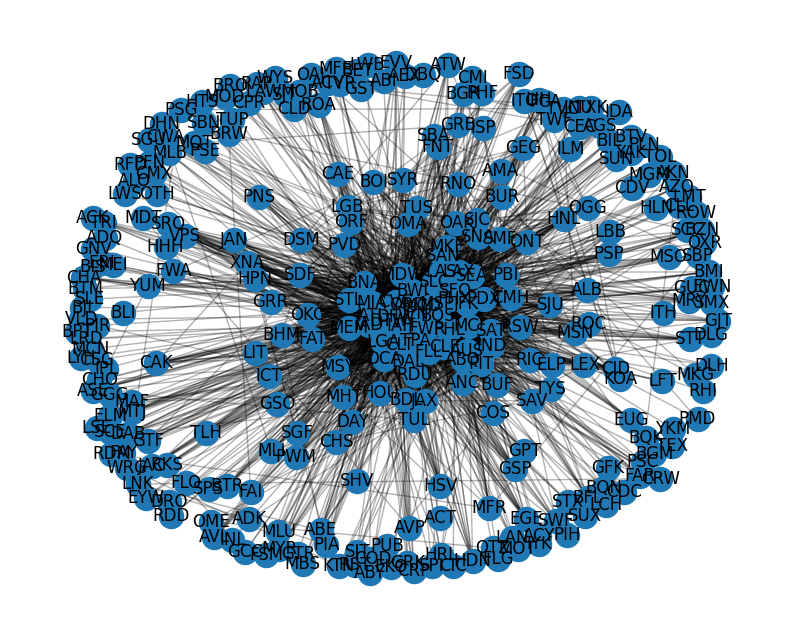

In [199]:
plt.figure(figsize=(10, 8))
pos=nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos=pos)
nx.draw_networkx_edges(G, pos=pos, alpha=0.3)
nx.draw_networkx_labels(G, pos=pos)
plt.axis('off')
plt.show()

In [211]:
def median_infection_time(infected_counts):
    airports = dict()

    first_date = None
    
    for infections in infected_counts:
        for airport, date in infections.items():
            if first_date:
                first_date = min(first_date, date)
            else:
                first_date = date
            if airport in airports:
                airports[airport].append(date)
            else:
                airports[airport] = [date]
    
    medians = {airport: np.median([(date - first_date).total_seconds() for date in dates]) / 60 / 60 / 24 for airport, dates in airports.items()}    
    
    return medians 

In [213]:
simulations_50 = run_simulations(data, 0.5, n=50, random_state=4200)

Симуляция для p=0.5: 100%|██████████| 50/50 [20:34<00:00, 24.70s/it]


In [239]:
median_simulations_50 = median_infection_time(simulations_50)
clustering = nx.clustering(G, weight='weight')
degrees = nx.degree(G, weight='weight')
centrality = nx.betweenness_centrality(G, weight='weight')

In [341]:
airport_to_metrics = pd.DataFrame(columns=["median", "cluster", "degree", "central"])

get_value = lambda x, arr: arr[x] if x in arr else pd.NA

for node in G.nodes():
    median = get_value(node, median_simulations_50)
    cluster = clustering[node]
    degree = degrees[node]
    central = centrality[node]
    
    airport_to_metrics.loc[node] = {"median": median, "cluster": cluster, "degree": degree, "central": central}

# airport_to_metrics = pd.DataFrame(columns=airport_to_metrics.columns, data=MinMaxScaler().fit_transform(airport_to_metrics))

/tmp/ipykernel_2335035/2590830054.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  airport_to_metrics.loc[node] = {"median": median, "cluster": cluster, "degree": degree, "central": central}


In [342]:
airport_to_metrics

,median,cluster,degree,central
MFE,1.936111,0.093718,0.001166,0.000000
HLN,2.262500,0.088934,0.000568,0.000000
OME,2.895833,0.039150,0.000297,0.000000
RFD,2.204861,0.000000,0.000083,0.000000
PHX,1.854167,0.053891,0.057421,0.019802
...,...,...,...,...
BFL,1.946528,0.066657,0.001299,0.000000
FSM,1.872222,0.115175,0.000830,0.000000
JAC,2.009028,0.049207,0.001067,0.000000
MLI,1.833333,0.077527,0.002414,0.000000


<Axes: xlabel='central', ylabel='median'>

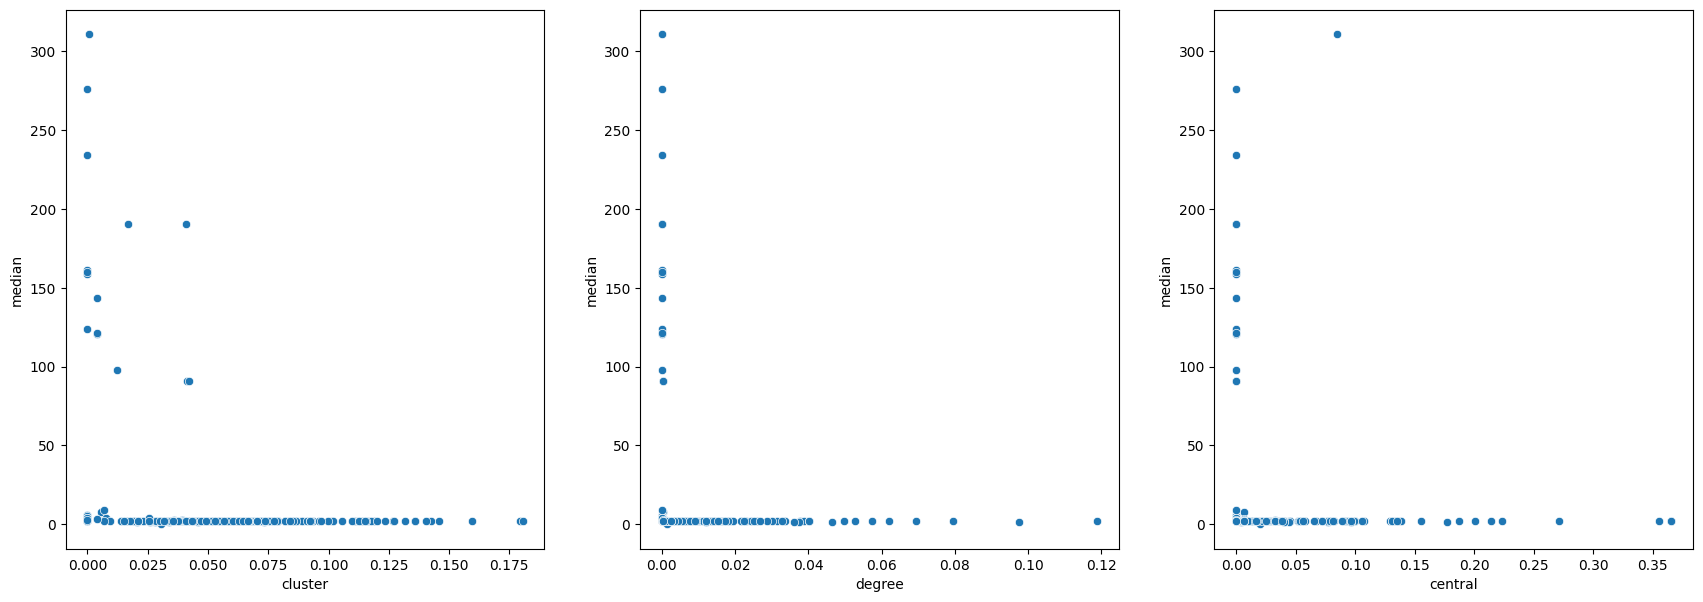

In [343]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21,7))
sns.scatterplot(x=airport_to_metrics.cluster, y=airport_to_metrics["median"], ax=ax1)
sns.scatterplot(x=airport_to_metrics.degree, y=airport_to_metrics["median"], ax=ax2)
sns.scatterplot(x=airport_to_metrics.central, y=airport_to_metrics["median"], ax=ax3)

<Axes: >

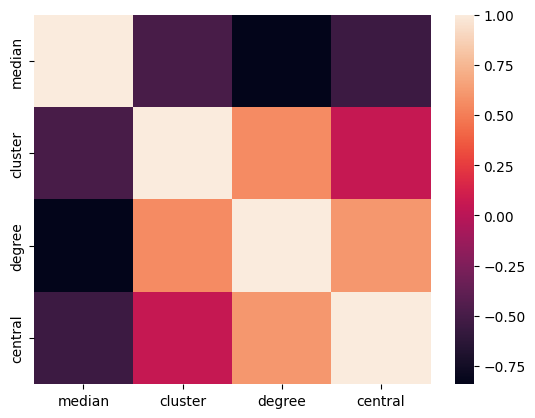

In [344]:
sns.heatmap(airport_to_metrics.corr(method='spearman'))

<Axes: >

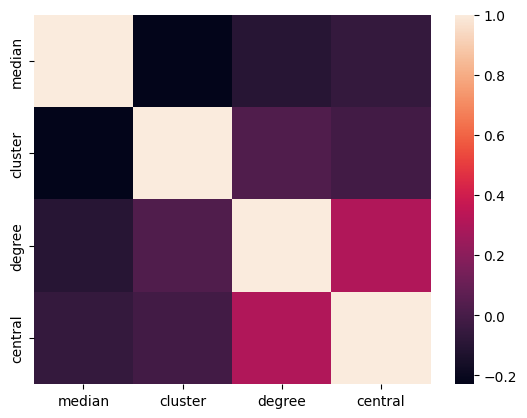

In [345]:
sns.heatmap(airport_to_metrics.corr(method='pearson'))